In [ ]:
# Scarichiamo il dataset (archivio zip)
!wget https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip

# Scompattiamo il file principale
!unzip -q pamap2+physical+activity+monitoring.zip

# Scompattiamo il file interno che contiene i dati veri e propri
!unzip -q PAMAP2_Dataset.zip

--2026-06-30 14:54:44--  https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘pamap2+physical+activity+monitoring.zip’

pamap2+physical+act     [<=>                 ] 656.34M  94.6MB/s    in 6.8s    

2026-06-30 14:54:51 (96.0 MB/s) - ‘pamap2+physical+activity+monitoring.zip’ saved [688226940]



Creating the data frame

In [ ]:
import pandas as pd
import numpy as np

# Definiamo i nomi delle colonne principali che useremo per iniziare
# Nota: per semplicità partiamo solo con timestamp, attività, battito e l'accelerometro del braccio (hand)
columns_to_keep = [0, 1, 2, 3, 4, 5]
column_names = ['timestamp', 'activity_id', 'heart_rate', 'acc_hand_x', 'acc_hand_y', 'acc_hand_z']

# Carichiamo il file del Soggetto 101
df = pd.read_csv('PAMAP2_Dataset/Protocol/subject101.dat', sep=' ', header=None, usecols=columns_to_keep)
df.columns = column_names

print(f"Formato del dataset: {df.shape}")
df.head()

Formato del dataset: (376417, 6)


,timestamp,activity_id,heart_rate,acc_hand_x,acc_hand_y,acc_hand_z
0,8.38,0,104.0,30.0,2.37223,8.60074
1,8.39,0,NaN,30.0,2.18837,8.56560
2,8.40,0,NaN,30.0,2.37357,8.60107
3,8.41,0,NaN,30.0,2.07473,8.52853
4,8.42,0,NaN,30.0,2.22936,8.83122


##Data Cleaning
Activity ID = 0: represent the moments in which the subject was not completing any specific activity

Removing missing data (NaNs)

In [ ]:
# 1. Rimuoviamo l'attività 0
df = df[df['activity_id'] != 0]

# 2. Gestiamo i valori mancanti (NaN) usando il metodo "forward fill"
# (copia l'ultimo valore valido noto per riempire il vuoto)
df = df.ffill()

# Se rimangono dei NaN all'inizio del file, li eliminiamo
df = df.dropna()

print(f"Formato dopo la pulizia: {df.shape}")

Formato dopo la pulizia: (249953, 6)


## Exploring the dataset

In [ ]:
# Mappa parziale dei codici attività di PAMAP2
activity_mapping = {
    1: 'Lying',
    2: 'Sitting',
    3: 'Standing',
    4: 'Walking',
    5: 'Running',
    6: 'Cycling',
    7: 'Nordic Walking'
}
df['activity_name'] = df['activity_id'].map(activity_mapping)

Walking

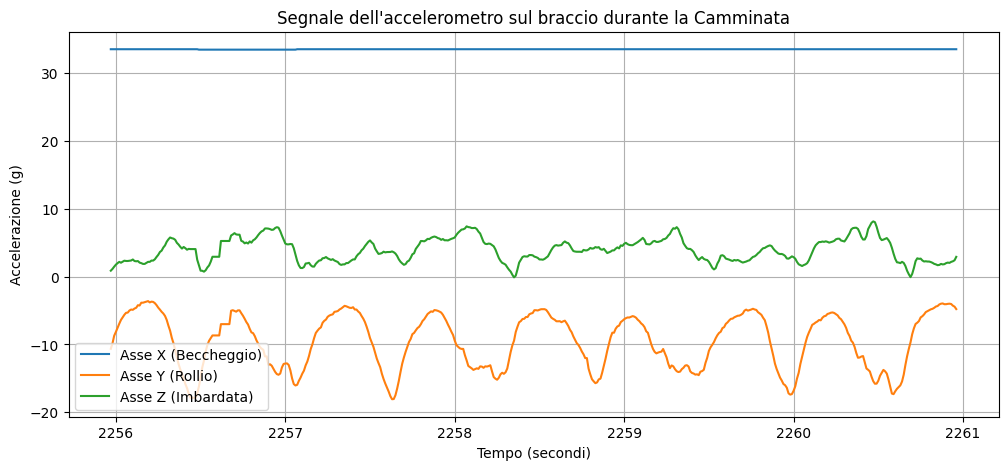

In [ ]:
import matplotlib.pyplot as plt

# Prendiamo un frammento di dati in cui l'utente sta camminando (es. Walking, ID 4)
walking_data = df[df['activity_id'] == 4].iloc[1000:1500] # 500 campioni = 5 secondi

plt.figure(figsize=(12, 5))
plt.plot(walking_data['timestamp'], walking_data['acc_hand_x'], label='Asse X (Beccheggio)')
plt.plot(walking_data['timestamp'], walking_data['acc_hand_y'], label='Asse Y (Rollio)')
plt.plot(walking_data['timestamp'], walking_data['acc_hand_z'], label='Asse Z (Imbardata)')
plt.title('Segnale dell\'accelerometro sul braccio durante la Camminata')
plt.xlabel('Tempo (secondi)')
plt.ylabel('Accelerazione (g)')
plt.legend()
plt.grid(True)
plt.show()

Running

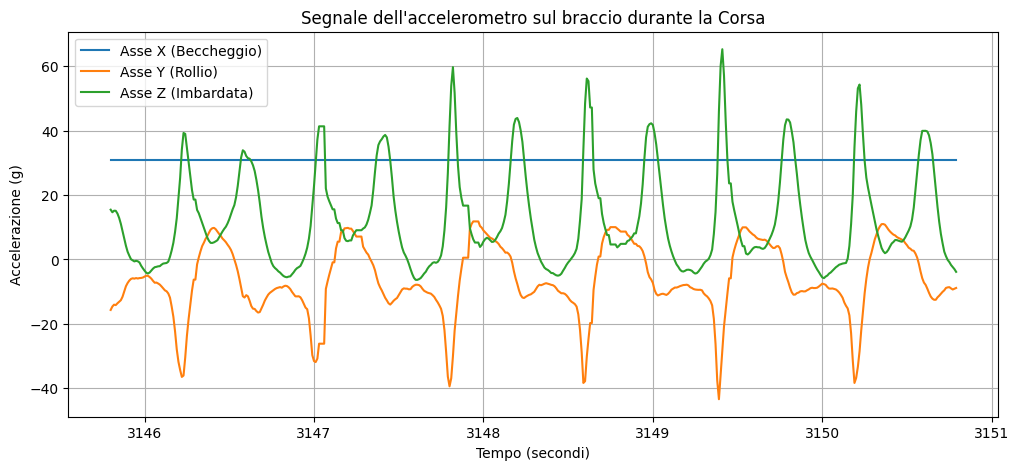

In [ ]:
import matplotlib.pyplot as plt

# Prendiamo un frammento di dati in cui l'utente sta correndo (es. Running, ID 4)
running_data = df[df['activity_id'] == 5].iloc[1000:1500] # 500 campioni = 5 secondi

plt.figure(figsize=(12, 5))
plt.plot(running_data['timestamp'], running_data['acc_hand_x'], label='Asse X (Beccheggio)')
plt.plot(running_data['timestamp'], running_data['acc_hand_y'], label='Asse Y (Rollio)')
plt.plot(running_data['timestamp'], running_data['acc_hand_z'], label='Asse Z (Imbardata)')
plt.title('Segnale dell\'accelerometro sul braccio durante la Corsa')
plt.xlabel('Tempo (secondi)')
plt.ylabel('Accelerazione (g)')
plt.legend()
plt.grid(True)
plt.show()

## Why is X component constant?

In [ ]:
print("Min X:", walking_data['acc_hand_x'].min(), "Max X:", walking_data['acc_hand_x'].max())

Min X: 33.4375 Max X: 33.5


## Defining the time window
The sampling frequency of this dataset is 100 Hz.
In the literature, usually the window for activities like walking or running is from 2.5 to 5 seconds.
I'll use 5 second windows for now, then each segment will contain:

5 Seconds * 100 Hz = 500 data rows

Here, we will have 50% overlap to avoid losing events at the segment extremes.

In [ ]:
def create_windows(df, window_size=500, step_size=250):
    """
    Scompone il dataframe in finestre temporali sovrapposte.
    window_size = 500 (5 secondi a 100Hz)
    step_size = 250 (50% di overlap, si sposta di 2.5 secondi alla volta)
    """
    windows = []
    labels = []

    # Estraiamo solo le colonne dei sensori (escludiamo timestamp e activity_id)
    feature_cols = ['heart_rate', 'acc_hand_x', 'acc_hand_y', 'acc_hand_z']
    data = df[feature_cols].values
    activity_labels = df['activity_id'].values

    for i in range(0, len(data) - window_size, step_size):
        # Estraiamo la finestra di dati
        window = data[i:i + window_size]

        # Per l'etichetta (label), prendiamo l'attività più frequente in quella finestra
        # (Nel caso in cui l'utente abbia cambiato attività a metà finestra)
        label = pd.Series(activity_labels[i:i + window_size]).mode()[0]

        windows.append(window)
        labels.append(label)

    return np.array(windows), np.array(labels)

# Applichiamo la funzione al nostro DataFrame pulito
X, y = create_windows(df, window_size=500, step_size=250)

print(f"Forma dell'input X (Finestre, Campioni, Sensori): {X.shape}")
print(f"Forma dell'output y (Etichette): {y.shape}")

Forma dell'input X (Finestre, Campioni, Sensori): (998, 500, 4)
Forma dell'output y (Etichette): (998,)


## CNN 1D

### Final data preparation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Normalizziamo i dati dei sensori (Media = 0, Varianza = 1)
# Per farlo sulle serie temporali 3D, dobbiamo "appiattirle" temporaneamente
num_windows, window_size, num_features = X.shape
X_flat = X.reshape(-1, num_features)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
X_scaled = X_flat_scaled.reshape(num_windows, window_size, num_features)

# 2. Codifichiamo le etichette in numeri sequenziali (es: 1,4,5 -> 0,1,2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# 3. Dividiamo in Train set (80%) e Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"Classi totali identificate: {num_classes}")

### Definition of the 1D CCN

In [ ]:
def build_cnn1d_model(input_shape, num_classes):
    model = models.Sequential([
        # Primo blocco convoluzionale
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2), # Previene l'overfitting

        # Secondo blocco convoluzionale
        layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Appiattimento e strati densi (Fully Connected)
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        # Strato di output (uno per ogni attività sportiva)
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Istanziamo il modello basandoci sulla forma dei nostri dati
model = build_cnn1d_model(input_shape=(window_size, num_features), num_classes=num_classes)
model.summary()

### Model compiling and training

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Addestriamo il modello
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

###Accuracy curves

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuratezza del Modello')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Perdita (Loss) del Modello')
plt.legend()
plt.show()